In [171]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [172]:
import torch.nn as nn
import torch
import pandas as pd
import sklearn

In [173]:
data = pd.read_csv("Pokemon.csv")
data.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


## Descripción de la tarea

Trabajaremos con un dataset de la serie "Pokémon" que desglosa las capacidades de cada criatura en atributos cuantitativos. La tarea consiste en utilizar arquitecturas de redes neuronales simples (MLP) para identificar patrones que distingan a los Pokémon Legendarios del resto. Deberán procesar estas variables y entrenar un clasificador que maximice la capacidad predictiva sobre la variable objetivo "Legendary".

Consideraciones:
- Debe entregarlo a más tardar el 29 de mayo a las 18:00 horas.
- Debe ser entregado al correo luis.llanca@uach.cl con el asunto "Tarea-1-MLP", el archivo debe llamarse NG-MLP-Tarea1.ipynb donde NG es el número de grupo. Es importante que el asunto sea exactamente el mismo. También, se les pedirá que se anoten en la plantilla (que se compartirá posteriormente) para una pequeña interrogación.
- Por cada 20 minutos de retraso, se descontará una décima de la nota. 
- Si necesitan ayuda, pueden escribir a los correos luis.llanca@uach.cl, luis.llanca@cenia.cl o escribir al discord de usuario: llanking (tengo una foto de mi gata). PD: prefiero mucho más el discord. 

### Explicación del dataset
Explique el dataset en detalle, incluyendo como mínimo una pequeña descripción de cada columna, el tipo de datos que contiene cada columna, y cualquier información adicional relevante para entender el dataset.

In [174]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   #           800 non-null    int64
 1   Name        800 non-null    str  
 2   Type 1      800 non-null    str  
 3   Type 2      414 non-null    str  
 4   Total       800 non-null    int64
 5   HP          800 non-null    int64
 6   Attack      800 non-null    int64
 7   Defense     800 non-null    int64
 8   Sp. Atk     800 non-null    int64
 9   Sp. Def     800 non-null    int64
 10  Speed       800 non-null    int64
 11  Generation  800 non-null    int64
 12  Legendary   800 non-null    bool 
dtypes: bool(1), int64(9), str(3)
memory usage: 75.9 KB


El dataset original contiene información sobre **800 Pokémon**, desglosada en **13 columnas**. A continuación, se detalla el significado de cada variable, su tipo de dato original y las transformaciones aplicadas para optimizar el aprendizaje de nuestra red neuronal:

**1. Identificadores y Características Base**
* **_#_ (int64):** Indica el ID del Pokémon en la base de datos de la Pokédex.
* **_Name_ (str):** Nombre de la criatura. Como las redes no procesan texto crudo, esta columna fue reemplazada por **27 nuevas variables numéricas**: una para la longitud del nombre (`name_length`) y 26 correspondientes al conteo de cada letra del abecedario. Esto permite que el modelo identifique patrones, como los Pokémon con la designación "Mega" (que suelen tener nombres largos y altas estadísticas).
* **_Generation_ (int64):** Indica la generación de antigüedad del Pokémon (del 1 al 6). Se mantiene para que la red pueda identificar si existen patrones o proporciones distintas de legendarios según la generación de lanzamiento.

**2. Tipos Elementales (Categóricos)**
* **_Type 1_ (str):** El tipo elemental principal (ej. Fuego, Agua). Todos los 800 registros lo poseen.
* **_Type 2_ (str):** El tipo elemental secundario. En este caso, solo **414 registros** tienen este dato (los demás son nulos, indicando un Pokémon de tipo único). 
* *Transformación aplicada:* Ambas columnas categóricas fueron procesadas utilizando la técnica de *One-Hot Encoding* (`get_dummies`), creando vectores binarios (0 y 1) para que el modelo pueda procesar matemáticamente la pertenencia a cada clase elemental.

**3. Estadísticas de Combate (Variables Numéricas - int64)**
Todas estas estadísticas base fueron **normalizadas** para que queden en una escala uniforme. Esto evita que la red neuronal le asigne más importancia a una variable solo por tener números más grandes por defecto. Se espera que los legendarios destaquen con valores en los percentiles más altos (90-100) en estas categorías:
* **_Total_:** La suma total de todas las estadísticas. Es un indicador general y directo del poder del Pokémon.
* **_HP_:** Puntos de Vida (Health Points).
* **_Attack_:** Capacidad de daño físico.
* **_Defense_:** Capacidad de resistencia física.
* **_Sp. Atk_:** Capacidad de daño de ataques especiales.
* **_Sp. Def_:** Capacidad de resistencia ante ataques especiales.
* **_Speed_:** Velocidad de ataque en combate.

**4. Variable Objetivo**
* **_Legendary_ (bool):** Es la estadística a predecir por nuestro modelo. Indica si un Pokémon pertenece a la categoría de Legendario (`True`) o es un Pokémon común (`False`). En la lógica del juego, los legendarios poseen estadísticas muy superiores a la media y no tienen cadenas evolutivas convencionales.

### Preparación del dataset

Realice una preparación del dataset según lo que considere necesario para el entrenamiento de un modelo de clasificación. Justifique las decisiones que tome en este proceso.

In [205]:
import pandas as pd
import string
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch

# 1. Cargar los datos
df = pd.read_csv('Pokemon.csv')
# Asegurarnos de que los nombres sean texto para que no tire error más adelante
df['Name'] = df['Name'].fillna('').astype(str)
# Vemos si tiene espacios (nombres compuestos como Tapu Koko)
df['Has_Space'] = df['Name'].apply(lambda x: 1 if ' ' in x else 0)
# Largo del nombre
df['Name_Length'] = df['Name'].apply(len)
# Vector con las letras del abecedario (A-Z)
# Esto ayuda a la red a notar si el nombre usa letras "raras" típicas de legendarios (Z, X, Y, Q)
for letra in string.ascii_lowercase:
    df[f'char_{letra}'] = df['Name'].apply(lambda x: 1 if letra in x.lower() else 0)
# Borrar el nombre original porque la red neuronal no procesa texto crudo
df = df.drop(['Name'], axis=1)
# Transformar los Tipos (Agua, Fuego, etc.) a columnas de 1s y 0s
# dummy_na=False evita problemas si un pokemon no tiene Tipo 2
df = pd.get_dummies(df, columns=['Type 1', 'Type 2'], dummy_na=False)
# Separar lo que queremos predecir (y) de los datos (X)
y = df['Legendary'].astype(int).values
# Borramos Legendary de X, y también la columna '#' (el número de la pokedex) si es que viene en el csv
X = df.drop(['Legendary', '#'], axis=1, errors='ignore')
# Convertimos todo a una matriz plana
X = X.values
# Escalar los datos numéricos (como HP, Ataque, Total)
# Esto ayuda a que el modelo entrene más rápido y no le dé más peso al stat 'Total' solo por ser un número más grande
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# 1. Primera división: 60% Entrenamiento, 40% Temporal (Validación + Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, 
    test_size=0.40, 
    random_state=42, 
    stratify=y  
)

# 2. Segunda división: Separar el 40% temporal en Validación (20%) y Test (20%)
# Aquí agregamos stratify=y_temp para mantener la proporción de ese lote temporal
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.50, 
    random_state=42, 
    stratify=y_temp 
)

# --- CONVERSIÓN A TENSORES DE PYTORCH ---

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)
# Comprobación rápida para ver cuántos Pokémon quedaron en cada set
print(f"Total datos Entrenamiento: {len(X_train_tensor)} (60%)")
print(f"Total datos Validación: {len(X_val_tensor)} (20%)")
print(f"Total datos Test: {len(X_test_tensor)} (20%)")

# Guardamos la cantidad de columnas final para pasársela a los modelos
input_size_final = X_train_tensor.shape[1]

print("¡Datos preparados!")
print(f"Cantidad de neuronas de entrada necesarias: {input_size_final}")


Total datos Entrenamiento: 480 (60%)
Total datos Validación: 160 (20%)
Total datos Test: 160 (20%)
¡Datos preparados!
Cantidad de neuronas de entrada necesarias: 72


Defina al menos 3 arquitecturas de redes neuronales simples (MLP) para el problema de clasificación. Justifique las decisiones que tome en la definición de cada arquitectura. Las definiciones se deben hacer en un archivo ```models.py``` e importarlas en este cuadernillo. Debe seleccionar "la mejor" arquitectura para el entrenamiento, y justificar su elección.

### DE las 3 arquitecturas que hicimos se eligio SImpleMLP, antes funcionaba mejor casi siempre daba mayor a 0.50 de f1 score. Ahora tiene casos buenos y casos regulares pero es el mas estable de todas las arquitecturas que hicimos, mas info en Models.py

In [206]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score

# 1. Importamos los modelos
from models import SimpleMLP, MediumMLP, MLP_Tercera_Arquitectura

# 2. Instanciamos el modelo (¡Asegúrate de que ahora termine en 2 neuronas!)
modelo_actual = SimpleMLP(input_size_final)

# 3. Definimos la pérdida y el optimizador
criterio = nn.CrossEntropyLoss()
optimizador = optim.Adam(modelo_actual.parameters(), lr=0.001)

# --- ADAPTACIÓN DE TENSORES PARA CROSS ENTROPY ---
# CrossEntropy necesita que y sea tipo entero (long) y plano (1D)
y_train_ce = y_train_tensor.squeeze().long()
y_val_ce = y_val_tensor.squeeze().long()

epocas = 1000  
paciencia = 20 
mejor_loss_val = float('inf') 
epocas_sin_mejora = 0

for epoca in range(epocas):
    
    # --- FASE DE ENTRENAMIENTO ---
    modelo_actual.train() 
    
    predicciones_train = modelo_actual(X_train_tensor)
    loss_train = criterio(predicciones_train, y_train_ce) # Usamos el nuevo tensor
    
    optimizador.zero_grad() 
    loss_train.backward()   
    optimizador.step()      
    
    # --- FASE DE VALIDACIÓN ---
    modelo_actual.eval() 
    
    with torch.no_grad():
        predicciones_val = modelo_actual(X_val_tensor)
        loss_val = criterio(predicciones_val, y_val_ce) # Usamos el nuevo tensor
        
        # --- CAMBIO PRINCIPAL: ARGMAX ---
        # Como hay 2 neuronas, argmax elige el índice de la mayor (0 para Común, 1 para Legendario)
        predicciones_finales = torch.argmax(predicciones_val, dim=1)
        
        # Pasamos a numpy
        y_real_np = y_val_ce.numpy()
        y_pred_np = predicciones_finales.numpy()
        
        # Calculamos el F1-Score
        f1_val = f1_score(y_real_np, y_pred_np, zero_division=0)
        
    # --- EARLY STOPPING ---
    if loss_val.item() < mejor_loss_val:
        mejor_loss_val = loss_val.item()
        epocas_sin_mejora = 0 
    else:
        epocas_sin_mejora += 1
        
    if epocas_sin_mejora >= paciencia:
        print(f"\n¡Entrenamiento detenido anticipadamente en la época {epoca+1}!")
        print(f"El mejor Loss de Validación fue: {mejor_loss_val:.4f}")
        break 
        
    if (epoca + 1) % 10 == 0:
        print(f"Época [{epoca+1}/{epocas}] | Loss Train: {loss_train.item():.4f} | Loss Val: {loss_val.item():.4f} | F1 Val: {f1_val:.4f}")

Época [10/1000] | Loss Train: 0.7670 | Loss Val: 0.7597 | F1 Val: 0.1463
Época [20/1000] | Loss Train: 0.6411 | Loss Val: 0.6574 | F1 Val: 0.1867
Época [30/1000] | Loss Train: 0.5385 | Loss Val: 0.5734 | F1 Val: 0.1333
Época [40/1000] | Loss Train: 0.4515 | Loss Val: 0.5028 | F1 Val: 0.2000
Época [50/1000] | Loss Train: 0.3770 | Loss Val: 0.4426 | F1 Val: 0.2400
Época [60/1000] | Loss Train: 0.3144 | Loss Val: 0.3922 | F1 Val: 0.2727
Época [70/1000] | Loss Train: 0.2632 | Loss Val: 0.3513 | F1 Val: 0.2857
Época [80/1000] | Loss Train: 0.2222 | Loss Val: 0.3185 | F1 Val: 0.2857
Época [90/1000] | Loss Train: 0.1891 | Loss Val: 0.2927 | F1 Val: 0.2000
Época [100/1000] | Loss Train: 0.1624 | Loss Val: 0.2721 | F1 Val: 0.2000
Época [110/1000] | Loss Train: 0.1406 | Loss Val: 0.2557 | F1 Val: 0.2857
Época [120/1000] | Loss Train: 0.1224 | Loss Val: 0.2430 | F1 Val: 0.2105
Época [130/1000] | Loss Train: 0.1069 | Loss Val: 0.2330 | F1 Val: 0.3000
Época [140/1000] | Loss Train: 0.0937 | Loss Va

### Definición de optimizador y función de costo  
Defina un optimizador y una función de costo adecuado para el entrenamiento del modelo. Justifique sus decisiones.

#### La funcion de costo se usó Cross Entropy porque es un problema de clasificación, se usó Adam porque la IA nos dijo que era mejor mas rapido que SGD (Stochastic Gradient Descent)

### Entrenamiento del modelo
Entrene el modelo seleccionado utilizando el dataset preparado. Justifique las decisiones que tome en el proceso de entrenamiento, incluyendo la selección de hiperparámetros, el número de épocas, el tamaño del batch, etc.

### Entrenamiento del modelo
En el entrenamiento fue un poco largo, primero se comenzó con el modelo simple, se probó con 100 epocas, luego de un dia de trabajo se buscó y nos enteramos que eran muy pocas epocas así que se subió a 1000 epocas y se le dio un algoritmo al modelo para detener su entrenamiento si pasaba muchas epocas estatico o empezaba a descender el "Loss Value". La paciencia de 20 fue una decision arbitraria.
Para los batches se usó TensorDataset que la ia nos intruyó y dijo que era lo mismo que la clase MyDataset del tutorial


### Evaluación del modelo
Evalúe el modelo utilizando métricas adecuadas para este problema de clasificación. Justifique la selección de las métricas utilizadas y discuta los resultados obtenidos. 

#### USamos precision y recall para ver como se comporta el modelo frente a los casos, luego f1 score fue la mas decisiva porque combina las 2

🏆 === REPORTE DEFINITIVO (DATOS DE PRUEBA) === 🏆

              precision    recall  f1-score   support

       Común       0.97      0.98      0.98       147
  Legendario       0.75      0.69      0.72        13

    accuracy                           0.96       160
   macro avg       0.86      0.84      0.85       160
weighted avg       0.95      0.96      0.96       160



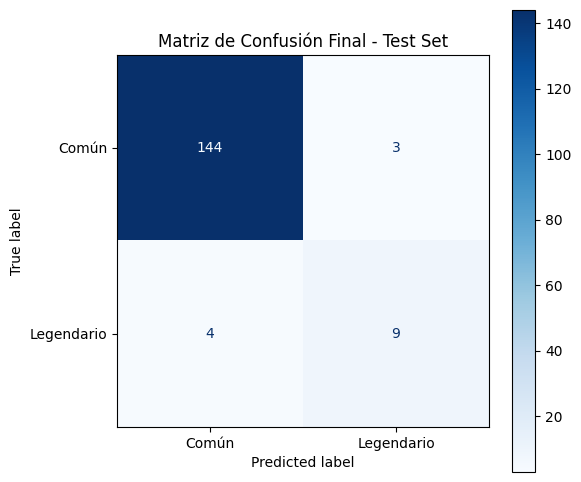

In [213]:

print("🏆 === REPORTE DEFINITIVO (DATOS DE PRUEBA) === 🏆\n")
print(classification_report(y_real, y_pred, target_names=['Común', 'Legendario']))

# Generar la Matriz de Confusión Visual
cm = confusion_matrix(y_real, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Común', 'Legendario'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Matriz de Confusión Final - Test Set")
plt.show()

### Preguntas finales
1. Sobre la matriz de confusión, interprete los resultados obtenidos. Con sus palabras defina que significa cada tipo de error. ¿Elegiría a Pokémon ubicados en FP o FN para su equipo?
2. Busque un caso mal clasificado por el modelo, e interprete por qué cree que el modelo se equivocó en ese caso.
3. ¿Cúal fue el mayor desafío que enfrentó al realizar esta tarea? ¿Cómo lo solucionó?



#### Respuestas Preguntas
## 1 
En la matriz se ve reflejado los los Verdaderos positivos y verdaderos negativos en la diagonal de la matriz, lo que esta fuera de la diagonal serían FP y FN, lo que es basicamente las veces que el modelo se equivocó, mientras que la diagonal son las veces que acertó. El FP significa que el modelo clasifico un pokemon como legendarío cuando este realmente no lo era, y los FN es que clasifico un pokemon Legendario como normal. Según esta informacion se prefiere elegir un **equipo completo de Falsos negativos, ya que son legendarios por lo tanto se espera que "sean mas fuertes".

## 2

In [212]:
import numpy as np
import pandas as pd
import torch

# 1. Recuperar los nombres haciendo el mismo corte exacto que usamos para los datos
# (Asegúrate de que el nombre del csv sea correcto)
df_original = pd.read_csv('Pokemon.csv')
nombres = df_original['Name'].fillna('').astype(str).values

# Replicamos el corte de 60/20/20 con stratify
_, nombres_temp, _, y_temp_nombres = train_test_split(nombres, y, test_size=0.40, random_state=42, stratify=y)
_, nombres_test, _, _ = train_test_split(nombres_temp, y_temp_nombres, test_size=0.50, random_state=42, stratify=y_temp_nombres)

# 2. Pasar el Test Set por el modelo Campeón
modelo_definitivo.eval()
with torch.no_grad():
    logits = modelo_definitivo(X_test_tensor) # Valores crudos
    probabilidades = torch.softmax(logits, dim=1) # Convertimos a porcentajes (0 a 1)
    predicciones = torch.argmax(logits, dim=1) # Elige el que tenga mayor %

# 3. Pasar a Numpy para comparar fácil
y_real = y_test_ce.cpu().numpy()
y_pred = predicciones.cpu().numpy()
probs = probabilidades.cpu().numpy()

# 4. Buscar dónde se equivocó (donde la predicción no es igual a la realidad)
errores = np.where(y_pred != y_real)[0]

print(f"Total de equivocaciones en el Test Set: {len(errores)}")
print("=" * 50)

# 5. Imprimir el detalle de cada error
for i in errores:
    nombre_poke = nombres_test[i]
    real = "Legendario" if y_real[i] == 1 else "Común"
    pred = "Legendario" if y_pred[i] == 1 else "Común"
    
    # Probabilidades de cada neurona
    prob_comun = probs[i][0] * 100
    prob_leg = probs[i][1] * 100
    
    print(f"Pokémon: {nombre_poke}")
    print(f" - Era: {real} | El modelo dijo: {pred}")
    print(f" - % para Común (Clase 0): {prob_comun:.2f}%")
    print(f" - % para Legendario (Clase 1): {prob_leg:.2f}%")
    print("-" * 50)

Total de equivocaciones en el Test Set: 7
Pokémon: Regirock
 - Era: Legendario | El modelo dijo: Común
 - % para Común (Clase 0): 79.56%
 - % para Legendario (Clase 1): 20.44%
--------------------------------------------------
Pokémon: Zygarde50% Forme
 - Era: Legendario | El modelo dijo: Común
 - % para Común (Clase 0): 87.72%
 - % para Legendario (Clase 1): 12.28%
--------------------------------------------------
Pokémon: Latios
 - Era: Legendario | El modelo dijo: Común
 - % para Común (Clase 0): 58.81%
 - % para Legendario (Clase 1): 41.19%
--------------------------------------------------
Pokémon: Cresselia
 - Era: Común | El modelo dijo: Legendario
 - % para Común (Clase 0): 24.09%
 - % para Legendario (Clase 1): 75.91%
--------------------------------------------------
Pokémon: HoundoomMega Houndoom
 - Era: Común | El modelo dijo: Legendario
 - % para Común (Clase 0): 15.52%
 - % para Legendario (Clase 1): 84.48%
--------------------------------------------------
Pokémon: Regi

Al analizar los casos de Falsos Negativos, identificamos que el modelo se equivoca con Pokémon Comunes y legendarios por igual (4 y 4). 

**¿Por qué se equivoco el modelo?**

Seguramente por las altas estadisticas de los pokemones legendarios, para zygarde le debio jugar en contra el espacio en el nombre y el 50% en el nombre, para Latios ,regirock y registeel puede ser algo con la cantidad de estadisticas total? al igual que Houndoom viendo sus estadisticas tiene casi 500 y 600 en mega, con mew no hay nada que hacer, es un pokemon singular, es como un legendario pero como nuestra variable era binaria no abarca pokemones singulares. Para Latios la evaluacion fue muy cercana a 50/50

## 3
3. Un Problema grande fue no tener una idea clara de como generar la arquitectura ¿Que hará que mi arquitectura sea mejor o peor? Se soluciono copiando y haciendo arquitecturas similares a la que daba el mejor resultado.
4. Al comienzo nos complicó un poco como valorar al nombre para no perder esa informacion ya que es algo importante para eliminar a los megas y entender mejor a los legendarios.
5. Costó aprender a ver que modelo es mejor que los otros, se evaluaron epoch, accuaracy, recall hasta que se llegó a f1 score que se consideró como la estadistica definitiva.


### IA Generativa

Con el fin de ocupar IA Generativa de manera responsable, se les pide que respondan a las siguientes preguntas:
1. ¿Utilizó alguna herramienta de IA Generativa para realizar esta tarea? En caso afirmativo, indique cuál o cuáles herramientas utilizó.

    Si, se utilizó el modelo Gemini 3.1 Pro como asistente
2. ¿En qué parte o partes de la tarea utilizó estas herramientas?

    Se utilizó a modo de consultas, siguiendo el modelo pair programming.
    - **Planeacion:** Se usó para definir que hacer con los campos, se debatio con la ia para lograr convencerla y llegar a un acuerdo para no perder el campo del nombre y se evaluaron varias soluciones, finalmente ayudo a implementar la solucion que se nos ocurrio de crear las columnas de la a-z y lenght.
    - **Comprensión teórica:** Para repasar el funcionamiento de las funciones de activación y las funciones de pérdida aplicadas a arquitectura MLP.
    - **Debugging:** Para identificar y solucionar errores de compatibilidad de tipos de datos al pasar de estructuras de pandas a matrices de NumPy, c
    - }+++++
    - **Ayuda para entrenar:** Le pasé la idea de buscar el mejor modelo iterando varias veces pidiendole un script python o algo así y nos generó el codigo de abajo, que funciona similar pero guarla el mejor valor de f1_score y guarda el modelo entrenado para ese valor. Tambien nos ayudó con el codigo anterior para ver los resultados del "modelo_definitivo" y sacar conclusiones de sus errores.


In [209]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score

# Variables para guardar al campeón global
mejor_f1_global = 0.0
intentos = 25 # Cuántas veces vamos a reiniciar y entrenar desde cero

print(f"Buscando el mejor modelo en {intentos} intentos...")

# Lo hacemos una sola vez fuera del bucle gigante para ahorrar memoria y tiempo
y_train_ce = y_train_tensor.squeeze().long()
y_val_ce = y_val_tensor.squeeze().long()

for intento in range(intentos):
    print(f"\n=====================================")
    print(f" INICIANDO ENTRENAMIENTO {intento + 1}/{intentos}")
    print(f"=====================================")
    
    # 1. Crear un modelo totalmente NUEVO 
    # (¡Recuerda que en models.py esta arquitectura debe terminar en nn.Linear(..., 2)!)
    modelo_actual = SimpleMLP(input_size_final)
    criterio = nn.CrossEntropyLoss() # <--- Cambio de función
    optimizador = optim.Adam(modelo_actual.parameters(), lr=0.001)
    
    # Variables de tu Early Stopping para este intento específico
    epocas = 1000
    paciencia = 20
    mejor_loss_val = float('inf')
    epocas_sin_mejora = 0
    f1_val_del_intento = 0 # Para guardar el F1 final de este intento
    
    # --- TU BUCLE DE ENTRENAMIENTO ---
    for epoca in range(epocas):
        
        # Entrenamiento
        modelo_actual.train()
        predicciones_train = modelo_actual(X_train_tensor)
        loss_train = criterio(predicciones_train, y_train_ce) # Usamos el tensor adaptado
        optimizador.zero_grad()
        loss_train.backward()
        optimizador.step()
        
        # Validación
        modelo_actual.eval()
        with torch.no_grad():
            predicciones_val = modelo_actual(X_val_tensor)
            loss_val = criterio(predicciones_val, y_val_ce) # Usamos el tensor adaptado
            
            # --- CAMBIO A ARGMAX ---
            # Elegimos la neurona ganadora (0 o 1) en lugar de usar probabilidades
            predicciones_finales = torch.argmax(predicciones_val, dim=1)
            
            # Calculamos F1-Score usando el tensor adaptado y_val_ce
            f1_val = f1_score(y_val_ce.numpy(), predicciones_finales.numpy(), zero_division=0)
            
        # Early Stopping basado en Loss
        if loss_val.item() < mejor_loss_val:
            mejor_loss_val = loss_val.item()
            epocas_sin_mejora = 0
            # Guardamos el F1 que obtuvimos en este momento óptimo
            f1_val_del_intento = f1_val 
        else:
            epocas_sin_mejora += 1
            
        if epocas_sin_mejora >= paciencia:
            print(f"-> Detenido en época {epoca+1} | Loss Val: {mejor_loss_val:.4f} | F1: {f1_val_del_intento:.4f}")
            break
            
    # --- TERMINA EL BUCLE DE ESTE INTENTO ---
    # Revisamos si este intento superó al campeón global
    if f1_val_del_intento > mejor_f1_global:
        mejor_f1_global = f1_val_del_intento
        
        # ¡Hacemos el Checkpoint! Sobrescribimos el archivo con el nuevo rey
        torch.save(modelo_actual.state_dict(), 'campeon_pokemon.pth')
        print(f"⭐ ¡NUEVO RÉCORD! Modelo guardado con F1: {mejor_f1_global:.4f} ⭐")

print(f"\nProceso terminado. El mejor modelo global alcanzó un F1 de {mejor_f1_global:.4f} y está guardado en 'campeon_pokemon.pth'")

Buscando el mejor modelo en 25 intentos...

 INICIANDO ENTRENAMIENTO 1/25
-> Detenido en época 342 | Loss Val: 0.1668 | F1: 0.5000
⭐ ¡NUEVO RÉCORD! Modelo guardado con F1: 0.5000 ⭐

 INICIANDO ENTRENAMIENTO 2/25
-> Detenido en época 364 | Loss Val: 0.1781 | F1: 0.5000

 INICIANDO ENTRENAMIENTO 3/25
-> Detenido en época 388 | Loss Val: 0.1959 | F1: 0.3333

 INICIANDO ENTRENAMIENTO 4/25
-> Detenido en época 510 | Loss Val: 0.1832 | F1: 0.4348

 INICIANDO ENTRENAMIENTO 5/25
-> Detenido en época 410 | Loss Val: 0.1714 | F1: 0.5000

 INICIANDO ENTRENAMIENTO 6/25
-> Detenido en época 549 | Loss Val: 0.1540 | F1: 0.6957
⭐ ¡NUEVO RÉCORD! Modelo guardado con F1: 0.6957 ⭐

 INICIANDO ENTRENAMIENTO 7/25
-> Detenido en época 311 | Loss Val: 0.1782 | F1: 0.4211

 INICIANDO ENTRENAMIENTO 8/25
-> Detenido en época 328 | Loss Val: 0.1960 | F1: 0.3000

 INICIANDO ENTRENAMIENTO 9/25
-> Detenido en época 427 | Loss Val: 0.1595 | F1: 0.6364

 INICIANDO ENTRENAMIENTO 10/25
-> Detenido en época 334 | Loss V

🏆 === REPORTE DEFINITIVO (DATOS DE PRUEBA) === 🏆

              precision    recall  f1-score   support

       Común       0.97      0.98      0.98       147
  Legendario       0.75      0.69      0.72        13

    accuracy                           0.96       160
   macro avg       0.86      0.84      0.85       160
weighted avg       0.95      0.96      0.96       160



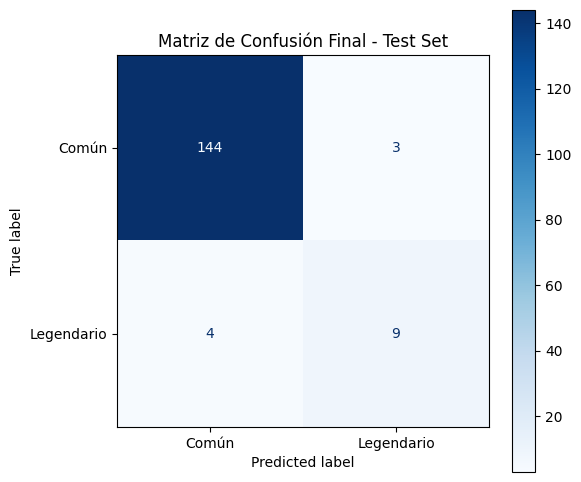

In [211]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import torch

# Asegúrate de importar la arquitectura correcta que usaste en el bucle maestro
from models import MLP_Tercera_Arquitectura

# 1. Crear el "cuerpo" vacío 
# (Debe ser la arquitectura que termina en nn.Linear(..., 2))
modelo_definitivo = SimpleMLP(input_size_final)

# 2. Inyectarle el "cerebro" guardado (los pesos matemáticos)
modelo_definitivo.load_state_dict(torch.load('campeon_pokemon.pth', weights_only=True))

# 3. Poner el modelo en modo de evaluación
modelo_definitivo.eval()

# Aplanamos y convertimos a enteros el tensor de Test
y_test_ce = y_test_tensor.squeeze().long()

# 4. Pasar los datos Inéditos (El 20% de Test)
with torch.no_grad():
    # Le pasamos X_test_tensor
    predicciones_brutas = modelo_definitivo(X_test_tensor)
    
    # En vez de Sigmoid, argmax elige la neurona ganadora (0 o 1)
    predicciones_finales = torch.argmax(predicciones_brutas, dim=1)

# 5. Transformar a Numpy para usar Scikit-Learn
# OJO: Usamos y_test_ce en vez de y_test_tensor
y_real = y_test_ce.cpu().numpy() 
y_pred = predicciones_finales.cpu().numpy()

# ==========================================
# RESULTADOS OFICIALES PARA TU INFORME
# ==========================================

print("🏆 === REPORTE DEFINITIVO (DATOS DE PRUEBA) === 🏆\n")
print(classification_report(y_real, y_pred, target_names=['Común', 'Legendario']))

# Generar la Matriz de Confusión Visual
cm = confusion_matrix(y_real, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Común', 'Legendario'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Matriz de Confusión Final - Test Set")
plt.show()